# Data understanding

This notebook inspects the raw IBM Telco Customer Churn dataset before any transformation. The objective is to understand the target, data types, data quality and potential preprocessing requirements.

In [2]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/raw/telco_customer_churn.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Target and initial data-quality checks

Before modelling, we inspect the churn target, missing values and columns whose stored type does not match their analytical meaning.

In [4]:
target_distribution = (
    df["Churn"]
    .value_counts(dropna=False)
    .rename_axis("churn")
    .reset_index(name="customers")
)

target_distribution["percentage"] = (
    target_distribution["customers"] / len(df) * 100
).round(1)

target_distribution

,churn,customers,percentage
0,No,5174,73.5
1,Yes,1869,26.5


In [5]:
quality_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "blank_strings": df.astype(str).apply(
            lambda column: column.str.strip().eq("").sum()
        ),
        "unique_values": df.nunique(),
    }
).sort_values(
    ["missing_values", "blank_strings"],
    ascending=False,
)

quality_summary

,dtype,missing_values,blank_strings,unique_values
TotalCharges,str,0,11,6531
customerID,str,0,0,7043
gender,str,0,0,2
SeniorCitizen,int64,0,0,2
Partner,str,0,0,2
Dependents,str,0,0,2
tenure,int64,0,0,73
PhoneService,str,0,0,2
MultipleLines,str,0,0,3
InternetService,str,0,0,3


## Feature roles

Before preprocessing, we distinguish identifiers, the target variable and candidate predictor variables. Customer identifiers must not be used as model features.

In [6]:
column_profile = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "unique_values": df.nunique(),
        "sample_values": [
            ", ".join(df[column].astype(str).unique()[:3])
            for column in df.columns
        ],
    }
)

column_profile

,dtype,unique_values,sample_values
customerID,str,7043,"7590-VHVEG, 5575-GNVDE, 3668-QPYBK"
gender,str,2,"Female, Male"
SeniorCitizen,int64,2,"0, 1"
Partner,str,2,"Yes, No"
Dependents,str,2,"No, Yes"
tenure,int64,73,"1, 34, 2"
PhoneService,str,2,"No, Yes"
MultipleLines,str,3,"No phone service, No, Yes"
InternetService,str,3,"DSL, Fiber optic, No"
OnlineSecurity,str,3,"No, Yes, No internet service"


In [7]:
TARGET = "Churn"
ID_COLUMN = "customerID"

feature_columns = [
    column
    for column in df.columns
    if column not in [TARGET, ID_COLUMN]
]

print(f"Target: {TARGET}")
print(f"Identifier excluded: {ID_COLUMN}")
print(f"Candidate features: {len(feature_columns)}")
print(feature_columns)

Target: Churn
Identifier excluded: customerID
Candidate features: 19
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## Train-test split and leakage prevention

The test set represents unseen future data. It must be separated before fitting imputers, encoders, scalers or models, otherwise evaluation results may be overly optimistic.

In [8]:
from sklearn.model_selection import train_test_split

X = df[feature_columns].copy()

y = df[TARGET].map(
    {
        "No": 0,
        "Yes": 1,
    }
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 5634
Test rows: 1409


In [9]:
split_churn_rate = pd.DataFrame(
    {
        "training": y_train.value_counts(normalize=True),
        "test": y_test.value_counts(normalize=True),
    }
) * 100

split_churn_rate.round(1)

,training,test
Churn,,
0,73.5,73.5
1,26.5,26.5


## Preprocessing design

`TotalCharges` is converted to numeric deterministically. Missing-value imputation, scaling and categorical encoding are fitted on training data only through a scikit-learn pipeline.

In [10]:
import numpy as np

def clean_total_charges(frame: pd.DataFrame) -> pd.DataFrame:
    """Convert TotalCharges from raw text to numeric values."""
    cleaned = frame.copy()

    cleaned["TotalCharges"] = pd.to_numeric(
        cleaned["TotalCharges"],
        errors="coerce",
    )

    return cleaned


X_train = clean_total_charges(X_train)
X_test = clean_total_charges(X_test)

print(X_train["TotalCharges"].dtype)
print(f"Missing TotalCharges in training: {X_train['TotalCharges'].isna().sum()}")
print(f"Missing TotalCharges in test: {X_test['TotalCharges'].isna().sum()}")

float64
Missing TotalCharges in training: 8
Missing TotalCharges in test: 3


In [11]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

categorical_features = [
    column
    for column in feature_columns
    if column not in numeric_features
]

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {len(categorical_features)}")
print(categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: 16
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Reproducible preprocessing pipeline

Numeric features are imputed with the training median and scaled. Categorical features are imputed with the most frequent category and one-hot encoded. The complete preprocessing object can be reused unchanged for every model.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## Baseline model: logistic regression

A logistic-regression baseline provides an interpretable reference point. All preprocessing steps are included inside the model pipeline so that cross-validation fits them separately within each training fold.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                random_state=42,
            ),
        ),
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

### Cross-validation

We compare models using stratified five-fold cross-validation on training data. Accuracy alone is insufficient because churn is the minority class.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy",
}

baseline_cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

baseline_metrics = pd.Series(
    {
        metric.replace("test_", ""): scores.mean()
        for metric, scores in baseline_cv_results.items()
        if metric.startswith("test_")
    }
).sort_values(ascending=False)

baseline_metrics.round(3)


roc_auc      0.846
accuracy     0.803
precision    0.655
f1           0.593
recall       0.543
dtype: float64

## Tree-based model: Random Forest

Random Forest can learn non-linear relationships and interactions between customer attributes. It is compared against logistic regression using the same preprocessing and cross-validation strategy.

In [15]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [17]:
random_forest_cv_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

random_forest_metrics = pd.Series(
    {
        metric.replace("test_", ""): scores.mean()
        for metric, scores in random_forest_cv_results.items()
        if metric.startswith("test_")
    }
)

model_comparison = pd.DataFrame(
    {
        "logistic_regression": baseline_metrics,
        "random_forest": random_forest_metrics,
    }
)

model_comparison.round(3)

,logistic_regression,random_forest
accuracy,0.803,0.764
f1,0.593,0.633
precision,0.655,0.540
recall,0.543,0.765
roc_auc,0.846,0.845


## Model selection

ROC-AUC is used as the primary selection metric because it evaluates how well a model ranks customers by churn risk across possible decision thresholds.

In [20]:
selection_metric = "roc_auc"

selected_model_name = model_comparison.loc[
    selection_metric
].idxmax()

models = {
    "logistic_regression": baseline_model,
    "random_forest": random_forest_model,
}

selected_model = models[selected_model_name]

print(f"Selected model: {selected_model_name}")
print(
    f"Cross-validated {selection_metric}: "
    f"{model_comparison.loc[selection_metric, selected_model_name]:.3f}"
)

Selected model: logistic_regression
Cross-validated roc_auc: 0.846


## Final holdout evaluation

The selected pipeline is fitted on all training data and evaluated once on the untouched test set. This provides the final estimate of generalisation performance.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

selected_model.fit(X_train, y_train)

y_test_pred = selected_model.predict(X_test)
y_test_probability = selected_model.predict_proba(X_test)[:, 1]

test_metrics = pd.Series(
    {
        "roc_auc": roc_auc_score(y_test, y_test_probability),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "accuracy": accuracy_score(y_test, y_test_pred),
    }
)

test_metrics.round(3)

roc_auc      0.842
precision    0.657
recall       0.559
f1           0.604
accuracy     0.806
dtype: float64

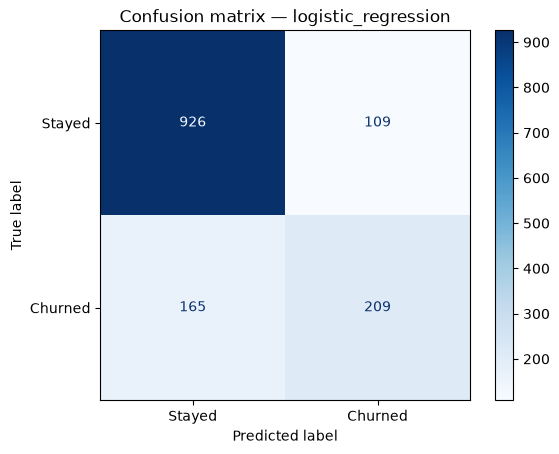

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
)

plt.title(f"Confusion matrix — {selected_model_name}")
plt.show()

## Global model interpretation

Permutation importance measures how much ROC-AUC decreases when the values of one feature are randomly shuffled. A larger decrease suggests that the model relies more on that feature for prediction.

In [22]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

feature_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values(
    "importance_mean",
    ascending=False,
)

feature_importance.head(10)

,feature,importance_mean,importance_std
4,tenure,0.168204,0.008157
7,InternetService,0.038680,0.006325
14,Contract,0.035235,0.003932
17,MonthlyCharges,0.031136,0.004903
18,TotalCharges,0.013411,0.003083
8,OnlineSecurity,0.003664,0.001514
13,StreamingMovies,0.003520,0.001598
12,StreamingTV,0.003422,0.002341
11,TechSupport,0.003241,0.001623
16,PaymentMethod,0.003019,0.001527


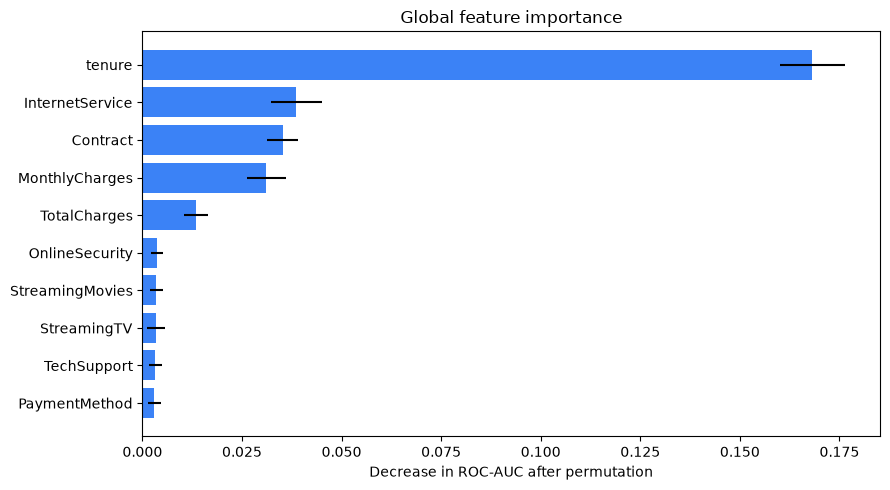

In [23]:
top_features = feature_importance.head(10).sort_values(
    "importance_mean",
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    color="#3B82F6",
)

plt.xlabel("Decrease in ROC-AUC after permutation")
plt.title("Global feature importance")
plt.tight_layout()
plt.show()